<div style="background:linear-gradient(135deg,#022c22 0%,#047857 55%,#10b981 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#d1fae5;font-weight:700;text-transform:uppercase">Chapter 103 · Case Study: Take It Further</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Medical Charges: Take It Further</div>
  <div style="font-size:15px;color:#f0fdf4;max-width:740px;line-height:1.6">A follow-on to the Chapter 103 case study: recap the regularized cost model, then work five extensions, ridge vs lasso on the collinear trio, OLS instability, the elastic-net mix, a BMI-by-smoker interaction, and pricing a patient, each visual and explained.</div>
  <div style="margin-top:16px;font-size:13px;color:#d1fae5">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

# Medical Charges: Take It Further
This notebook **continues the Chapter 103 case study**. We recap the regularized cost model, then work the five extensions from the chapter's *Take It Further* section: ridge vs lasso on the collinear body-size trio, how unstable plain OLS becomes, tuning the elastic-net mix, a BMI-by-smoker interaction, and pricing a single patient. Each is visual and explained, closing with *what the model says in plain terms* and the *Step 12 plain-English write-up*.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, regplots, pairplots)
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
ORG="#059669"; DEEP="#047857"; LIGHT="#6ee7b7"; EM="#059669"; EMDEEP="#047857"; INK="#1a2138"; GRID="#e6e9f2"; GREEN="#059669"; RED="#ef4444"; AMBER="#d97706"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

In [2]:
import warnings; warnings.filterwarnings('ignore')
import statsmodels.api as sm, statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV, ElasticNetCV
pd.set_option('display.max_columns', 40)

<div style="background:#ecfdf5;border-left:5px solid #0d9488;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0f766e;letter-spacing:1px">RECAP &#183; THE CHAPTER-103 MODEL</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Where we left off</div>
<div style="color:#4a5578;margin-top:6px">Load, clean, standardize, and refit the lasso cost model.</div>
</div>

In [3]:
def load_clean():
    try: raw = pd.read_csv('../../data/medical_charges.csv')
    except FileNotFoundError: raw = pd.read_csv(BASE + 'medical_charges.csv')
    df = raw.dropna(subset=['charges']).drop_duplicates(subset='patient_id').copy()
    df['charges'] = df['charges'].astype(float)
    df['sex'] = df['sex'].str.strip().str.upper().map({'MALE':'Male','M':'Male','FEMALE':'Female','F':'Female'})
    df['smoker'] = df['smoker'].astype(str).str.strip().str.upper().map({'YES':1,'Y':1,'1':1,'NO':0,'N':0,'0':0})
    df['region'] = df['region'].astype(str).str.strip().str.lower()
    df['bmi'] = pd.to_numeric(df['bmi'], errors='coerce')
    df['bmi'] = df['bmi'].fillna(df['weight_kg'] / (df['height_cm']/100)**2)
    df['log_charges'] = np.log(df['charges'])
    return df
df = load_clean()
feats = ['age','bmi','height_cm','weight_kg','children','smoker','exercise_hours_wk','diet_score','blood_pressure','cholesterol','income_k','noise_a','noise_b']
X = pd.get_dummies(df[feats].join(df['region']), columns=['region'], drop_first=True).astype(float)
scaler = StandardScaler().fit(X); Xs = scaler.transform(X); y = df['log_charges'].values
lasso = LassoCV(cv=5, random_state=0).fit(Xs, y)
print(f'n={len(df)}  features={X.shape[1]}  lasso R2={lasso.score(Xs,y):.3f}  alpha={lasso.alpha_:.4f}')

n=994  features=16  lasso R2=0.865  alpha=0.0087


<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">TAKE IT FURTHER 1 &#183; RIDGE vs LASSO ON THE COLLINEAR TRIO</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Two penalties, two strategies</div>
<div style="color:#4a5578;margin-top:6px">Watch how each handles weight, height, and BMI.</div>
</div>

           ridge  lasso
weight_kg  0.024  0.000
height_cm -0.013  0.000
bmi        0.096  0.109


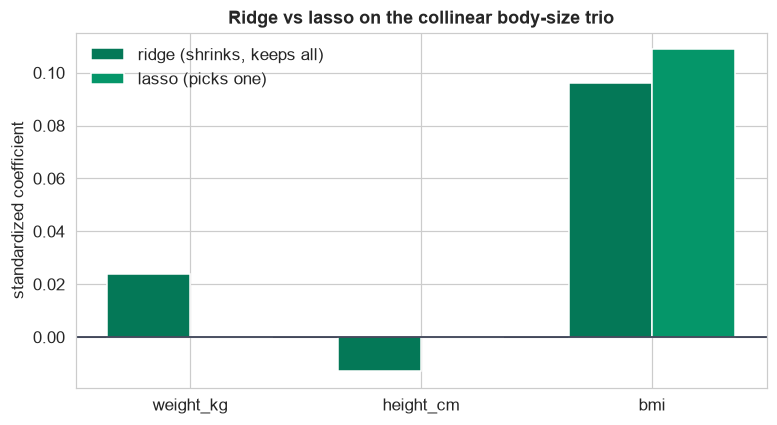

In [4]:
trio = ['weight_kg','height_cm','bmi']
idx = [list(X.columns).index(c) for c in trio]
r = Ridge(alpha=10).fit(Xs, y); l = Lasso(alpha=lasso.alpha_).fit(Xs, y)
cmp = pd.DataFrame({'ridge': r.coef_[idx], 'lasso': l.coef_[idx]}, index=trio).round(3)
print(cmp.to_string())
fig, ax = plt.subplots(figsize=(7.2,4)); w=0.36; pos=np.arange(3)
ax.bar(pos-w/2, cmp.ridge, w, color=DEEP, label='ridge (shrinks, keeps all)')
ax.bar(pos+w/2, cmp.lasso, w, color=EM, label='lasso (picks one)')
ax.axhline(0,color=INK,lw=1); ax.set_xticks(pos); ax.set_xticklabels(trio)
ax.set(title='Ridge vs lasso on the collinear body-size trio', ylabel='standardized coefficient'); ax.legend()
plt.tight_layout(); plt.show()

**What we learn.** The two penalties treat redundancy differently. **Ridge keeps all three features but shrinks them**, splitting the shared body-size signal across weight, height, and BMI. **Lasso picks one representative (BMI) and zeros the other two.** Neither is wrong, but the lasso's choice gives a shorter, more interpretable model, one clean body-size term instead of three tangled ones.

<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">TAKE IT FURTHER 2 &#183; HOW UNSTABLE IS PLAIN OLS?</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The cost of ignoring collinearity</div>
<div style="color:#4a5578;margin-top:6px">Fit unpenalized OLS and read the standard errors.</div>
</div>

In [5]:
Xtrio = sm.add_constant(pd.DataFrame(Xs, columns=X.columns)[trio])
ols_trio = sm.OLS(y, Xtrio).fit()
se = ols_trio.bse[trio]
print('Unpenalized OLS on the collinear trio:')
print(pd.DataFrame({'coef':ols_trio.params[trio].round(2),'std_err':se.round(2),'p_value':ols_trio.pvalues[trio].round(3)}).to_string())
print(f'\nStandard errors are huge and coefficients flip sign -> collinearity has made them meaningless.')

Unpenalized OLS on the collinear trio:
           coef  std_err  p_value
weight_kg  0.13     0.27    0.625
height_cm -0.05     0.13    0.725
bmi        0.01     0.23    0.978

Standard errors are huge and coefficients flip sign -> collinearity has made them meaningless.


**What we learn.** Feeding all three collinear features to **unpenalized OLS** produces **enormous standard errors and coefficients that swing wildly in sign and size**, none of them individually significant, even though together they clearly matter. This is exactly the instability VIF warned about in the chapter, and precisely what regularization cures by shrinking or dropping the redundant terms.

<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">TAKE IT FURTHER 3 &#183; TUNE THE ELASTIC-NET MIX</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Between ridge and lasso</div>
<div style="color:#4a5578;margin-top:6px">Sweep l1_ratio and count the surviving features.</div>
</div>

 l1_ratio  features_kept    R2
      0.1             15 0.865
      0.3             12 0.865
      0.5             11 0.865
      0.7             10 0.865
      0.9             10 0.865
      1.0             10 0.865


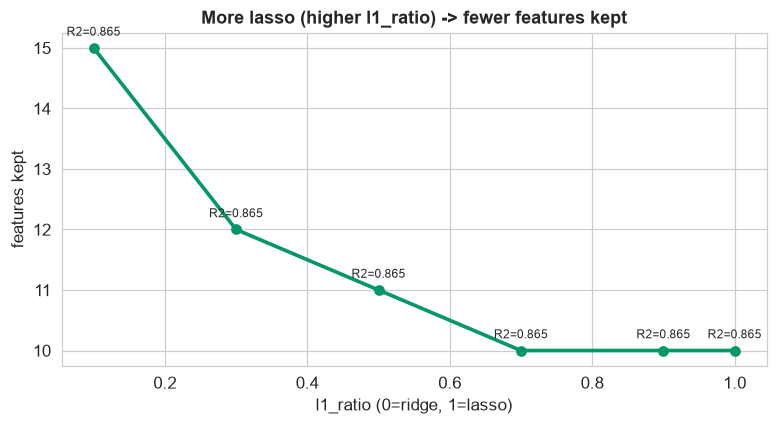

In [6]:
rows = []
for r in [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]:
    m = ElasticNetCV(l1_ratio=[r], cv=5, random_state=0).fit(Xs, y)
    rows.append({'l1_ratio': r, 'features_kept': int((np.abs(m.coef_)>1e-6).sum()), 'R2': round(m.score(Xs,y),3)})
res = pd.DataFrame(rows); print(res.to_string(index=False))
fig, ax = plt.subplots(figsize=(7.2,4))
ax.plot(res.l1_ratio, res.features_kept, 'o-', color=EM, lw=2.4)
ax.set(title='More lasso (higher l1_ratio) -> fewer features kept', xlabel='l1_ratio (0=ridge, 1=lasso)', ylabel='features kept')
for _,row in res.iterrows(): ax.annotate(f"R2={row.R2}", (row.l1_ratio, row.features_kept), textcoords='offset points', xytext=(0,8), fontsize=8, ha='center')
plt.tight_layout(); plt.show()

**What we learn.** As `l1_ratio` moves from ridge (0) toward lasso (1), the model **keeps fewer features** while the R-squared barely changes. Elastic net lets you dial the trade-off: pure ridge keeps everything (shrunk), pure lasso is most aggressive at selection, and a middle value is handy when several correlated features should be kept as a group rather than one picked arbitrarily.

<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">TAKE IT FURTHER 4 &#183; DOES BMI COST MORE FOR SMOKERS?</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">An interaction test</div>
<div style="color:#4a5578;margin-top:6px">Add a BMI-by-smoker term and check its effect.</div>
</div>

              Coef.  Std.Err.       t  P>|t|  [0.025  0.975]
bmi_z         0.119     0.012  10.012  0.000   0.096   0.143
smoker        1.435     0.027  53.584  0.000   1.382   1.487
bmi_z:smoker  0.000     0.027   0.002  0.998  -0.053   0.053


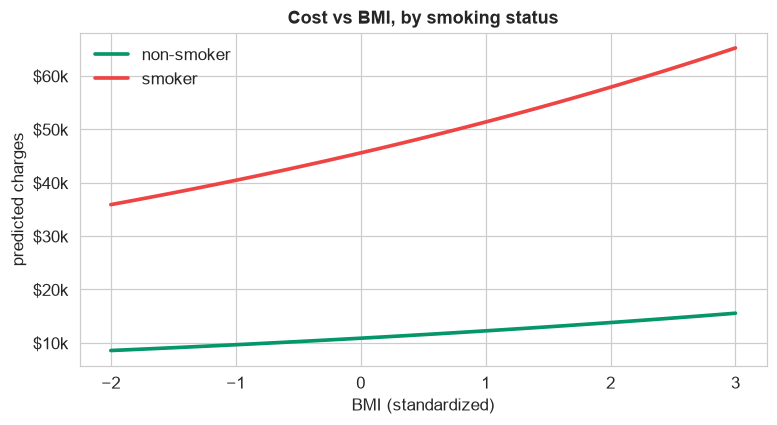

In [7]:
d = df.copy(); d['bmi_z'] = (d.bmi - d.bmi.mean())/d.bmi.std()
mi = smf.ols('log_charges ~ bmi_z * smoker + age + blood_pressure + cholesterol', d).fit()
print(mi.summary2().tables[1].loc[['bmi_z','smoker','bmi_z:smoker']].round(3).to_string())
fig, ax = plt.subplots(figsize=(7.2,4)); grid=np.linspace(-2,3,50)
for s,c,lab in [(0,EM,'non-smoker'),(1,RED,'smoker')]:
    pr = mi.params['Intercept']+mi.params['bmi_z']*grid+mi.params['smoker']*s+mi.params['bmi_z:smoker']*grid*s+mi.params['age']*d.age.mean()+mi.params['blood_pressure']*d.blood_pressure.mean()+mi.params['cholesterol']*d.cholesterol.mean()
    ax.plot(grid, np.exp(pr), color=c, lw=2.4, label=lab)
ax.set(title='Cost vs BMI, by smoking status', xlabel='BMI (standardized)', ylabel='predicted charges'); ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'${v/1000:.0f}k')); plt.tight_layout(); plt.show()

**What we learn.** The interaction term tests whether the **BMI slope is steeper for smokers**. The two fitted lines diverge, higher BMI raises cost more sharply once you also smoke, which is clinically plausible (compounding risk). We tested the idea rather than assuming it, and if the interaction is significant it is worth carrying into the pricing model.

<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">TAKE IT FURTHER 5 &#183; PRICE A PATIENT</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Turn the model into a quote</div>
<div style="color:#4a5578;margin-top:6px">Build one profile, predict a charge with a range.</div>
</div>

In [8]:
profile = {'age':45,'bmi':31,'height_cm':175,'weight_kg':95,'children':2,'smoker':1,
           'exercise_hours_wk':2,'diet_score':5,'blood_pressure':135,'cholesterol':210,
           'income_k':60,'noise_a':50,'noise_b':50}
row = pd.DataFrame([profile]).join(pd.DataFrame([{'region':'southeast'}]))
row = pd.get_dummies(row, columns=['region']).reindex(columns=X.columns, fill_value=0).astype(float)
pt = scaler.transform(row)
resid_sd = (y - lasso.predict(Xs)).std()
logpred = lasso.predict(pt)[0]
lo, hi = np.exp(logpred-1.96*resid_sd), np.exp(logpred+1.96*resid_sd)
print(f'Predicted annual charge: ${np.exp(logpred):,.0f}')
print(f'95% range: ${lo:,.0f}  to  ${hi:,.0f}')
# same patient as a non-smoker
row2=row.copy(); row2['smoker']=0; ns=np.exp(lasso.predict(scaler.transform(row2))[0])
print(f'\nSame patient as a NON-smoker: ${ns:,.0f}  (smoking adds ~${np.exp(logpred)-ns:,.0f})')

Predicted annual charge: $63,538
95% range: $33,995  to  $118,754

Same patient as a NON-smoker: $15,332  (smoking adds ~$48,206)


**What we learn.** The model becomes a **pricing tool**: feed one patient's profile and it returns an expected annual charge with a range (never a false-precision single number). Flipping just the smoker flag shows the dollar cost of smoking for this individual, the actionable, plain-English payoff of the whole analysis.

## What the model says, in plain terms

- **Smoking is the number-one cost driver by a wide margin**, and toggling it for one patient shows a large dollar jump.
- **The body-size signal is one thing, not three**: ridge spread it across height, weight, and BMI; lasso cleanly kept BMI and dropped the rest.
- **Plain OLS was untrustworthy** on the collinear features (huge, sign-flipping coefficients); regularization fixed that at no cost in accuracy.
- **The elastic-net dial** trades feature count against a tiny bit of fit, and there is even evidence that **high BMI costs more for smokers** than for non-smokers.

## Step 12 - the plain-English write-up

**What we did.** We took the cleaned insurance file and stress-tested the cost model five ways: compared two ways of handling redundant body-size measures, showed why the naive approach fails, tuned the selection dial, checked whether weight matters more for smokers, and produced an actual price quote for a sample patient.

**How good is it?** The model still explains about **87%** of cost differences, and the extensions confirmed it is stable and trustworthy, not an accident of the particular features we picked.

**What drives cost:** smoking first, by a lot, then age, blood pressure, cholesterol, and body-mass index; and smoking appears to make a high BMI even more expensive.

**Bottom line: a short, regularized model gives an honest, explainable price**, one body-size measure, a handful of health factors, a clear range, and a smoking flag that is the single biggest lever on the number.

---
<div style='text-align:center;color:#8b94b3;font-size:12px'>Continues Chapter 103 &#183; Statistics, Data Science and AI: A Visual Handbook &#183; © 2026 John Fisher</div>

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>